# Supervised survival-модель риска увольнения — ВКР (реальные данные)

Ноутбук обучает гибридную модель **LSTM + Attention + DeepSurv** на ~13K резюме
из парсера career-сервиса (всего 19 982, из них `with_work_experience = 13 329`).
**Никаких синтетических данных** — всё считается на реальных полях резюме.

## Схема меток

Для каждого резюме берётся **последнее по хронологии место работы**, и оттуда извлекаются метки:

| Состояние последней работы | `duration_months` | `event_observed` | Интерпретация |
|---|---|---|---|
| Завершена (`is_current = False`) | длительность работы | **1** | человек ушёл — событие наблюдалось |
| Текущая (`is_current = True`)    | длительность на момент парсинга | **0** | правосторонне цензурированное наблюдение |

**Защита от target leakage в последовательности.**
В job-векторе LSTM-входа последней работы (если `event=0`) поле `duration_months` зануляется
и помечается флагом `dur_missing=1`. Иначе нейросеть могла бы выучить тривиальное правило
«риск = -log(duration)». Для текущих работ это корректно: на момент инференса в продакшене
длительность текущей работы кандидата неизвестна.

## Что покрывает ноутбук

1. Загрузка реального JSONL → фильтрация по наличию `work_experience`.
2. Извлечение `(duration, event)` из последней работы.
3. Feature engineering: 22 числовых признака + LSTM-последовательность всей карьеры.
4. **Stratified** train/val split по `event_observed`.
5. Обучение **Bidirectional LSTM + Attention + DeepSurv** с mini-batch DataLoader.
6. Early stopping + CosineAnnealing LR scheduler.
7. Сравнение с 6 baseline-survival-моделями (Cox PH, Cox Elastic Net, Weibull AFT, RSF, GBSA, Extra Survival Trees).
8. C-index с **bootstrap 95% CI** + парный bootstrap-тест.
9. Kaplan–Meier по терцилям предсказанного риска, log-rank тест.
10. Индивидуальные `S(6m / 12m / 24m)` через Breslow.
11. Permutation importance + распределение attention-весов.
12. Сохранение модели и графиков для приложения ВКР.


## 1. Colab setup и зависимости

In [1]:
# Установка зависимостей
!pip -q install lifelines tqdm scikit-survival

import json, math, os, random, sys, time, hashlib, csv
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, List, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)


torch 2.10.0+cpu | device: cpu


### Пути и параметры эксперимента

In [2]:
USE_GOOGLE_DRIVE = True
DRIVE_DIR = Path("/content/drive/MyDrive/careerist_retention")

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        PROJECT_DIR = DRIVE_DIR
    except Exception as exc:
        print("Drive mount failed, falling back to local storage:", exc)
        PROJECT_DIR = Path(".")
else:
    PROJECT_DIR = Path(".")

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR  = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models" / "retention"
FIG_DIR   = PROJECT_DIR / "figures"
for d in (DATA_DIR, MODEL_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

RESUMES_JSONL = DATA_DIR / "careerist_resumes.jsonl"

# === Гиперпараметры модели (настроены под полную выборку ~13 000 записей) ===
TEXT_DIM        = 384
MAX_SEQ_LEN     = 12
HIDDEN_SIZE     = 128
NUM_LAYERS      = 2
BIDIRECTIONAL   = True
DROPOUT         = 0.3
MLP_HIDDEN      = 128

# Увеличен BATCH_SIZE для GPU-эффективности на большой выборке
BATCH_SIZE      = 512

# Больше эпох — достаточный объём данных для полноценного обучения
EPOCHS          = 100

LR              = 3e-4          # снижена для стабильного обучения
WEIGHT_DECAY    = 1e-4
GRAD_CLIP       = 5.0
WARMUP_EPOCHS   = 5             # увеличен прогрев
EARLY_STOP_PATIENCE = 15        # терпение увеличено

VAL_SHARE       = 0.2           # 80/20: ~10 660 train / ~2 660 val
HORIZONS        = [6.0, 12.0, 24.0]
SEED            = 42

# === Гигиена данных ===
MIN_LAST_JOB_DUR = 1.0   # минимум 1 месяц на последней работе

print("PROJECT_DIR:", PROJECT_DIR.resolve())
print("DEVICE     :", DEVICE)
print("Гиперпараметры настроены под полную выборку (~13 000 резюме)")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/MyDrive/careerist_retention
DEVICE     : cpu


## 2. Локальные модули модели

Записываем три модуля: `features_real.py` (адаптированный под last-job метки),
`torch_model_v2.py` (улучшенная архитектура: BiLSTM + 2 слоя + BatchNorm)
и `metrics.py` (без изменений).


In [3]:
MODULE_DIR = Path("careerist_retention_model")
MODULE_DIR.mkdir(exist_ok=True)
(MODULE_DIR / "__init__.py").write_text("__version__='0.3.0'\n", encoding="utf-8")


20

In [4]:
# metrics.py — оригинал из проекта (без изменений)
(MODULE_DIR / 'metrics.py').write_text('from __future__ import annotations\n\nimport math\nfrom bisect import bisect_right\nfrom typing import Dict, Iterable, List\n\n\ndef concordance_index(durations: Iterable[float], risk_scores: Iterable[float], events: Iterable[float]) -> float:\n    durations_arr = [float(value) for value in durations]\n    risks_arr = [float(value) for value in risk_scores]\n    events_arr = [float(value) for value in events]\n\n    concordant = 0.0\n    comparable = 0.0\n    n = len(durations_arr)\n    for i in range(n):\n        if events_arr[i] <= 0:\n            continue\n        for j in range(n):\n            if durations_arr[i] >= durations_arr[j]:\n                continue\n            comparable += 1.0\n            if risks_arr[i] > risks_arr[j]:\n                concordant += 1.0\n            elif abs(risks_arr[i] - risks_arr[j]) < 1e-12:\n                concordant += 0.5\n\n    if comparable == 0:\n        return float("nan")\n    return float(concordant / comparable)\n\n\ndef breslow_baseline_cumulative_hazard(\n    durations: Iterable[float],\n    events: Iterable[float],\n    log_risks: Iterable[float],\n) -> Dict[str, List[float]]:\n    durations_arr = [float(value) for value in durations]\n    events_arr = [float(value) for value in events]\n    risks_arr = [math.exp(float(value)) for value in log_risks]\n\n    event_times = sorted(set(time for time, event in zip(durations_arr, events_arr) if event > 0))\n    times: List[float] = []\n    cumulative: List[float] = []\n    total = 0.0\n    for time in event_times:\n        events_at_time = sum(1.0 for duration, event in zip(durations_arr, events_arr) if duration == time and event > 0)\n        at_risk_sum = sum(risk for duration, risk in zip(durations_arr, risks_arr) if duration >= time)\n        if at_risk_sum <= 0:\n            continue\n        total += events_at_time / at_risk_sum\n        times.append(time)\n        cumulative.append(total)\n    return {"times": times, "cumulative_hazard": cumulative}\n\n\ndef survival_at_horizons(log_risk: float, baseline: Dict[str, List[float]], horizons: Iterable[float]) -> Dict[str, float]:\n    times = [float(value) for value in baseline.get("times") or []]\n    hazards = [float(value) for value in baseline.get("cumulative_hazard") or []]\n    relative_risk = math.exp(float(log_risk))\n    result: Dict[str, float] = {}\n    for horizon in horizons:\n        key = f"survival_{int(horizon)}m"\n        if len(times) == 0:\n            result[key] = float("nan")\n            continue\n        index = bisect_right(times, float(horizon)) - 1\n        if index < 0:\n            baseline_hazard = 0.0\n        else:\n            baseline_hazard = float(hazards[index])\n        result[key] = math.exp(-baseline_hazard * relative_risk)\n    return result\n', encoding='utf-8')
print('metrics.py:', (MODULE_DIR / 'metrics.py').stat().st_size, 'bytes')


metrics.py: 2712 bytes


In [5]:
# torch_model_v2.py — BiLSTM + 2 слоя + BatchNorm
(MODULE_DIR / 'torch_model_v2.py').write_text('"""\nImproved hybrid survival model for resume career sequences.\nBidirectional LSTM + Attention + DeepSurv head with BatchNorm.\n"""\nfrom __future__ import annotations\nfrom typing import Tuple\n\nimport torch\nfrom torch import nn\n\n\nclass CareerLSTMAttentionDeepSurv(nn.Module):\n    def __init__(\n        self,\n        *,\n        seq_input_dim: int,\n        numeric_dim: int,\n        hidden_size: int = 128,\n        num_layers: int = 2,\n        dropout: float = 0.3,\n        mlp_hidden: int = 128,\n        bidirectional: bool = True,\n    ) -> None:\n        super().__init__()\n        lstm_dropout = dropout if num_layers > 1 else 0.0\n        self.bidirectional = bidirectional\n        self.lstm = nn.LSTM(\n            input_size=seq_input_dim,\n            hidden_size=hidden_size,\n            num_layers=num_layers,\n            batch_first=True,\n            dropout=lstm_dropout,\n            bidirectional=bidirectional,\n        )\n        lstm_out_dim = hidden_size * (2 if bidirectional else 1)\n        self.attention = nn.Sequential(\n            nn.Linear(lstm_out_dim, lstm_out_dim),\n            nn.Tanh(),\n            nn.Linear(lstm_out_dim, 1),\n        )\n        # Numeric branch with BN + Dropout\n        self.numeric_bn = nn.BatchNorm1d(numeric_dim) if numeric_dim > 0 else nn.Identity()\n        merged_dim = lstm_out_dim + numeric_dim\n        self.head = nn.Sequential(\n            nn.Linear(merged_dim, mlp_hidden),\n            nn.BatchNorm1d(mlp_hidden),\n            nn.ReLU(),\n            nn.Dropout(dropout),\n            nn.Linear(mlp_hidden, mlp_hidden // 2),\n            nn.BatchNorm1d(mlp_hidden // 2),\n            nn.ReLU(),\n            nn.Dropout(dropout * 0.5),\n            nn.Linear(mlp_hidden // 2, 1),\n        )\n\n    def forward(\n        self,\n        sequence: torch.Tensor,\n        lengths: torch.Tensor,\n        numeric: torch.Tensor,\n        *,\n        return_attention: bool = False,\n    ):\n        lengths_cpu = lengths.detach().cpu().clamp(min=1)\n        packed = nn.utils.rnn.pack_padded_sequence(\n            sequence, lengths_cpu, batch_first=True, enforce_sorted=False,\n        )\n        packed_outputs, _ = self.lstm(packed)\n        outputs, _ = nn.utils.rnn.pad_packed_sequence(\n            packed_outputs, batch_first=True, total_length=sequence.shape[1],\n        )\n\n        time_index = torch.arange(sequence.shape[1], device=sequence.device).unsqueeze(0)\n        mask = time_index < lengths.unsqueeze(1)\n        attention_logits = self.attention(outputs).squeeze(-1)\n        attention_logits = attention_logits.masked_fill(~mask, -1e9)\n        attention_weights = torch.softmax(attention_logits, dim=1)\n        pooled = torch.sum(outputs * attention_weights.unsqueeze(-1), dim=1)\n\n        numeric_n = self.numeric_bn(numeric) if numeric.shape[1] > 0 else numeric\n        merged = torch.cat([pooled, numeric_n], dim=1)\n        risk = self.head(merged).squeeze(-1)\n        if return_attention:\n            return risk, attention_weights\n        return risk\n\n\ndef cox_partial_likelihood_loss(\n    log_risk: torch.Tensor,\n    durations: torch.Tensor,\n    events: torch.Tensor,\n) -> torch.Tensor:\n    """Negative Cox partial log-likelihood, sorted by descending duration."""\n    order = torch.argsort(durations, descending=True)\n    ordered_log_risk = log_risk[order]\n    ordered_events = events[order]\n    log_cum_hazard = torch.logcumsumexp(ordered_log_risk, dim=0)\n    event_count = torch.clamp(ordered_events.sum(), min=1.0)\n    return -torch.sum((ordered_log_risk - log_cum_hazard) * ordered_events) / event_count\n', encoding='utf-8')
print('torch_model_v2.py:', (MODULE_DIR / 'torch_model_v2.py').stat().st_size, 'bytes')


torch_model_v2.py: 3546 bytes


In [6]:
# features_real.py — last-job метки + leakage-safe job vectors
(MODULE_DIR / 'features_real.py').write_text('"""\nFeature engineering for last-job survival labels.\n\nКаждое резюме рассматривается как один субъект.\n- Метка: из ПОСЛЕДНЕГО по хронологии места работы\n    duration = work_experience[-1].duration_months\n    event    = 1 if NOT period.is_current else 0\n- Признаки:\n    * `sequence`: вся карьера (включая последнюю работу), но для текущей работы\n      duration_months ЗАНУЛЯЕТСЯ + помечается dur_missing-флаг (защита от leakage).\n    * `numeric`: статичные поля профиля + агрегаты по всей карьере (но `current_job_duration`\n       и `total_experience_months` НЕ используются, потому что они напрямую содержат таргет).\n"""\nfrom __future__ import annotations\n\nimport hashlib\nimport json\nimport math\nimport re\nimport statistics\nfrom dataclasses import dataclass\nfrom pathlib import Path\nfrom typing import Any, Dict, List, Optional, Sequence, Tuple\n\nTOKEN_RE = re.compile(r"[a-zа-яё0-9+#.]+", re.IGNORECASE)\n# к каждому job-вектору добавляется 5 числовых: [log_dur, is_current_flag, position_norm, has_description, dur_missing]\nJOB_NUMERIC_FEATURES = 5\n\nNUMERIC_FEATURE_NAMES = [\n    "salary_log",\n    "salary_missing",\n    "history_job_count",\n    "history_avg_job_duration_months",\n    "history_median_job_duration_months",\n    "history_max_job_duration_months",\n    "history_min_job_duration_months",\n    "history_short_job_share_6m",\n    "history_short_job_share_12m",\n    "history_avg_gap_months",\n    "history_max_gap_months",\n    "history_career_span_months",\n    "history_has_any",\n    "education_count",\n    "courses_count",\n    "languages_count",\n    "skills_count",\n    "about_length_log",\n    "relocation_restricted",\n    "full_time_requested",\n    "salary_per_history_experience_log",\n    "has_higher_education",\n]\n\n\n@dataclass\nclass FeatureBatch:\n    resume_hashes: List[str]\n    sequence: List[List[List[float]]]\n    lengths: List[int]\n    numeric: List[List[float]]\n    numeric_feature_names: List[str]\n    text_dim: int\n    max_seq_len: int\n    durations: List[float]\n    events: List[int]\n    last_job_meta: List[Dict[str, Any]]\n\n    @property\n    def seq_input_dim(self) -> int:\n        if not self.sequence or not self.sequence[0]:\n            return self.text_dim + JOB_NUMERIC_FEATURES\n        return len(self.sequence[0][0])\n\n\n@dataclass\nclass NumericScaler:\n    mean: List[float]\n    scale: List[float]\n\n    @classmethod\n    def fit(cls, values: Sequence[Sequence[float]]) -> "NumericScaler":\n        if not values:\n            raise ValueError("Cannot fit scaler on empty matrix.")\n        cols = list(zip(*values))\n        mean = [sum(c) / len(c) for c in cols]\n        scale = []\n        for c, m in zip(cols, mean):\n            var = sum((v - m) ** 2 for v in c) / len(c)\n            std = math.sqrt(var)\n            scale.append(std if std >= 1e-6 else 1.0)\n        return cls(mean=mean, scale=scale)\n\n    def transform(self, values: Sequence[Sequence[float]]) -> List[List[float]]:\n        return [[(v - self.mean[i]) / self.scale[i] for i, v in enumerate(row)] for row in values]\n\n    def to_dict(self) -> Dict[str, Any]:\n        return {"mean": list(self.mean), "scale": list(self.scale)}\n\n\ndef load_resume_records(path: str | Path) -> List[Dict[str, Any]]:\n    records: List[Dict[str, Any]] = []\n    with Path(path).open("r", encoding="utf-8") as fh:\n        for ln, line in enumerate(fh, start=1):\n            line = line.strip()\n            if not line:\n                continue\n            try:\n                records.append(json.loads(line))\n            except json.JSONDecodeError as exc:\n                raise ValueError(f"Invalid JSONL at {path}:{ln}: {exc}") from exc\n    return records\n\n\ndef featurize_with_last_job_labels(\n    records: Sequence[Dict[str, Any]],\n    *,\n    text_dim: int = 384,\n    max_seq_len: int = 12,\n    min_last_job_dur: float = 1.0,\n) -> Tuple[FeatureBatch, Dict[str, int]]:\n    """Извлечь признаки и метки last-job survival из реальных резюме."""\n    if text_dim < 16:\n        raise ValueError("text_dim must be >= 16.")\n    if max_seq_len < 1:\n        raise ValueError("max_seq_len must be >= 1.")\n\n    seqs: List[List[List[float]]] = []\n    lens: List[int] = []\n    nums: List[List[float]] = []\n    hashes: List[str] = []\n    durations: List[float] = []\n    events: List[int] = []\n    last_meta: List[Dict[str, Any]] = []\n\n    stats = {\n        "total": 0,\n        "no_work_experience": 0,\n        "last_job_invalid_duration": 0,\n        "last_job_missing_duration": 0,\n        "kept": 0,\n        "kept_event_1": 0,\n        "kept_event_0": 0,\n    }\n\n    for row_index, rec in enumerate(records):\n        stats["total"] += 1\n        resume = rec.get("resume", {}) or {}\n        source = rec.get("source", {}) or {}\n        resume_hash = str(source.get("resume_hash") or f"row-{row_index}")\n\n        jobs_all = _chronological_jobs(resume.get("work_experience") or [])\n        if not jobs_all:\n            stats["no_work_experience"] += 1\n            continue\n\n        last_job = jobs_all[-1]\n        last_dur_raw = last_job.get("duration_months")\n        if last_dur_raw is None or last_dur_raw == "":\n            stats["last_job_missing_duration"] += 1\n            continue\n        last_dur = _safe_float(last_dur_raw)\n        if last_dur < min_last_job_dur:\n            stats["last_job_invalid_duration"] += 1\n            continue\n\n        last_period = last_job.get("period") or {}\n        is_current = bool(last_period.get("is_current"))\n        event = 0 if is_current else 1\n\n        # Полная карьера в LSTM, обрезанная справа до max_seq_len (берём самые свежие)\n        history_for_seq = jobs_all\n        if len(history_for_seq) > max_seq_len:\n            history_for_seq = history_for_seq[-max_seq_len:]\n\n        # last job — это история без последней; для numeric features используем "историю до последней"\n        history_for_numeric = jobs_all[:-1]\n\n        seq_row = [[0.0 for _ in range(text_dim + JOB_NUMERIC_FEATURES)] for _ in range(max_seq_len)]\n        last_in_seq_index = len(history_for_seq) - 1   # позиция последней работы в обрезанной последовательности\n        for j_idx, job in enumerate(history_for_seq):\n            # КРИТИЧНО: маскируем duration последнего эпизода ВСЕГДА (event=0 и event=1),\n            # т.к. duration_months последнего эпизода — это целевая переменная.\n            # Старая версия маскировала только is_current — прямая target leakage для event=1.\n            mask_duration = (j_idx == last_in_seq_index)\n            seq_row[j_idx] = _job_vector_label_safe(\n                job, j_idx, max_seq_len, text_dim, mask_duration=mask_duration\n            )\n\n        seqs.append(seq_row)\n        lens.append(max(1, len(history_for_seq)))\n        nums.append(_numeric_features(resume, history_for_numeric))\n        hashes.append(resume_hash)\n        durations.append(float(last_dur))\n        events.append(int(event))\n        last_meta.append({\n            "resume_hash": resume_hash,\n            "last_position": last_job.get("position"),\n            "last_industry": last_job.get("industry"),\n            "is_current": is_current,\n        })\n        stats["kept"] += 1\n        if event == 1:\n            stats["kept_event_1"] += 1\n        else:\n            stats["kept_event_0"] += 1\n\n    if not hashes:\n        raise ValueError("После фильтрации не осталось ни одного резюме.")\n\n    return (\n        FeatureBatch(\n            resume_hashes=hashes,\n            sequence=seqs,\n            lengths=lens,\n            numeric=nums,\n            numeric_feature_names=list(NUMERIC_FEATURE_NAMES),\n            text_dim=text_dim,\n            max_seq_len=max_seq_len,\n            durations=durations,\n            events=events,\n            last_job_meta=last_meta,\n        ),\n        stats,\n    )\n\n\ndef hashed_text_vector(text: str, dim: int = 384) -> List[float]:\n    vector = [0.0 for _ in range(dim)]\n    tokens = TOKEN_RE.findall((text or "").lower())\n    if not tokens:\n        return vector\n    feats = list(tokens)\n    feats.extend(f"{a}_{b}" for a, b in zip(tokens, tokens[1:]))\n    for tok in feats:\n        digest = hashlib.blake2b(tok.encode("utf-8"), digest_size=8).digest()\n        bucket = int.from_bytes(digest[:4], "little") % dim\n        sign = 1.0 if digest[4] % 2 == 0 else -1.0\n        vector[bucket] += sign\n    norm = math.sqrt(sum(v * v for v in vector))\n    if norm > 0:\n        vector = [v / norm for v in vector]\n    return vector\n\n\ndef _job_vector_label_safe(\n    job: Dict[str, Any],\n    job_index: int,\n    max_seq_len: int,\n    text_dim: int,\n    *,\n    mask_duration: bool,\n) -> List[float]:\n    """\n    Job vector for LSTM input.\n\n    Если mask_duration=True (текущая работа, которая является таргетом),\n    то duration_months зануляется и взводится dur_missing=1, чтобы не было target leakage.\n    """\n    description = job.get("description") or []\n    if isinstance(description, list):\n        desc_text = " ".join(str(x) for x in description[:8])\n    else:\n        desc_text = str(description)\n    text = " ".join(str(p) for p in [job.get("position"), job.get("industry"), desc_text] if p)\n    duration = _safe_float(job.get("duration_months"))\n    period = job.get("period") or {}\n\n    if mask_duration:\n        log_dur_norm = 0.0\n        dur_missing = 1.0\n    else:\n        log_dur_norm = math.log1p(duration) / math.log(241.0)\n        dur_missing = 0.0\n\n    return hashed_text_vector(text, text_dim) + [\n        log_dur_norm,\n        1.0 if period.get("is_current") else 0.0,\n        float(job_index + 1) / float(max_seq_len),\n        1.0 if desc_text.strip() else 0.0,\n        dur_missing,\n    ]\n\n\ndef _numeric_features(resume: Dict[str, Any], history: Sequence[Dict[str, Any]]) -> List[float]:\n    """Численные признаки. Используем только историю ДО последней работы для агрегатов длительности,\n       чтобы не было target leakage."""\n    durations = [_safe_float(j.get("duration_months")) for j in history if _safe_float(j.get("duration_months")) > 0]\n    if durations:\n        avg_d = sum(durations) / len(durations)\n        med_d = float(statistics.median(durations))\n        max_d = max(durations)\n        min_d = min(durations)\n        short_6 = sum(1 for d in durations if d < 6) / len(durations)\n        short_12 = sum(1 for d in durations if d < 12) / len(durations)\n    else:\n        avg_d = med_d = max_d = min_d = short_6 = short_12 = 0.0\n\n    gaps, span = _gaps_and_span(history)\n    salary = resume.get("salary") or {}\n    salary_amount = _safe_float(salary.get("amount"))\n    history_exp = sum(durations)\n    about_len = len(str(resume.get("about") or ""))\n    relocation = str(resume.get("relocation") or "").lower()\n    employment = str(resume.get("employment_type") or "").lower()\n    salary_per_exp = salary_amount / max(history_exp, 1.0)\n\n    education = resume.get("education") or []\n    has_higher = 0.0\n    for ed in education:\n        level = str(ed.get("level") or ed.get("name") or "").lower()\n        if any(k in level for k in ("высш", "магистр", "бакалавр", "специалист", "higher", "master", "bachelor")):\n            has_higher = 1.0\n            break\n\n    return [\n        math.log1p(salary_amount),\n        1.0 if salary_amount <= 0 else 0.0,\n        float(len(history)),\n        avg_d, med_d, max_d, min_d,\n        short_6, short_12,\n        (sum(gaps) / len(gaps)) if gaps else 0.0,\n        max(gaps) if gaps else 0.0,\n        span,\n        1.0 if len(history) > 0 else 0.0,\n        float(len(resume.get("education") or [])),\n        float(len(resume.get("courses") or [])),\n        float(len(resume.get("languages") or [])),\n        float(len(resume.get("skills") or [])),\n        math.log1p(about_len),\n        1.0 if "невозмож" in relocation else 0.0,\n        1.0 if "полная" in employment else 0.0,\n        math.log1p(salary_per_exp),\n        has_higher,\n    ]\n\n\ndef _chronological_jobs(jobs: Sequence[Dict[str, Any]]) -> List[Dict[str, Any]]:\n    indexed = list(enumerate(jobs))\n    if not indexed:\n        return []\n    def key(item):\n        idx, job = item\n        period = job.get("period") or {}\n        start = _ym_to_month_index(period.get("start"))\n        if start is None:\n            return (10**9, -idx)\n        return (start, idx)\n    return [job for _, job in sorted(indexed, key=key)]\n\n\ndef _gaps_and_span(jobs: Sequence[Dict[str, Any]]) -> Tuple[List[float], float]:\n    periods: List[Tuple[int, int]] = []\n    for job in jobs:\n        period = job.get("period") or {}\n        start = _ym_to_month_index(period.get("start"))\n        end = _ym_to_month_index(period.get("end"))\n        dur = int(_safe_float(job.get("duration_months")))\n        if start is None:\n            continue\n        if end is None:\n            end = start + max(dur, 1)\n        periods.append((start, max(end, start)))\n    if not periods:\n        return [], 0.0\n    periods.sort()\n    gaps: List[float] = []\n    prev_end = periods[0][1]\n    for s, e in periods[1:]:\n        gaps.append(float(max(0, s - prev_end)))\n        prev_end = max(prev_end, e)\n    span = float(max(e for _, e in periods) - min(s for s, _ in periods))\n    return gaps, span\n\n\ndef _ym_to_month_index(value: Any) -> Optional[int]:\n    if value is None:\n        return None\n    m = re.match(r"^(\\d{4})(?:-(\\d{2}))?$", str(value))\n    if not m:\n        return None\n    return int(m.group(1)) * 12 + int(m.group(2) or "1")\n\n\ndef _safe_float(value: Any) -> float:\n    if value in (None, ""):\n        return 0.0\n    try:\n        return float(value)\n    except (TypeError, ValueError):\n        return 0.0\n\n\ndef stratified_split(events: Sequence[int], val_share: float, seed: int) -> Tuple[List[int], List[int]]:\n    """Stratified train/val split по event_observed для сбалансированной валидации."""\n    rng = random.Random(seed)\n    idx_0 = [i for i, e in enumerate(events) if int(e) == 0]\n    idx_1 = [i for i, e in enumerate(events) if int(e) == 1]\n    rng.shuffle(idx_0); rng.shuffle(idx_1)\n    n0_val = max(1, int(round(len(idx_0) * val_share)))\n    n1_val = max(1, int(round(len(idx_1) * val_share)))\n    val = idx_0[:n0_val] + idx_1[:n1_val]\n    train = idx_0[n0_val:] + idx_1[n1_val:]\n    rng.shuffle(train); rng.shuffle(val)\n    return train, val\n\n\n# need random for stratified_split\nimport random\n', encoding='utf-8')
print('features_real.py:', (MODULE_DIR / 'features_real.py').stat().st_size, 'bytes')
print('Written:', sorted(p.name for p in MODULE_DIR.iterdir()))


features_real.py: 14655 bytes
Written: ['__init__.py', '__pycache__', 'features_real.py', 'metrics.py', 'torch_model_v2.py']


In [7]:
import sys
for m in list(sys.modules):
    if m.startswith("careerist_retention_model"):
        del sys.modules[m]
from careerist_retention_model import features_real as feat
from careerist_retention_model import torch_model_v2 as tm
from careerist_retention_model import metrics as mtr
print("features_real :", [x for x in dir(feat) if not x.startswith('_')][:6], '...')
print("torch_model_v2:", [x for x in dir(tm)   if not x.startswith('_')])
print("metrics       :", [x for x in dir(mtr)  if not x.startswith('_')])


features_real : ['Any', 'Dict', 'FeatureBatch', 'JOB_NUMERIC_FEATURES', 'List', 'NUMERIC_FEATURE_NAMES'] ...
torch_model_v2: ['CareerLSTMAttentionDeepSurv', 'Tuple', 'annotations', 'cox_partial_likelihood_loss', 'nn', 'torch']
metrics       : ['Dict', 'Iterable', 'List', 'annotations', 'bisect_right', 'breslow_baseline_cumulative_hazard', 'concordance_index', 'math', 'survival_at_horizons']


## 3. Загрузка реальных резюме

In [8]:
if not RESUMES_JSONL.exists():
    raise FileNotFoundError(
        f"Файл {RESUMES_JSONL} не найден. "
        f"Положите careerist_resumes.jsonl в {DATA_DIR}."
    )

resumes = feat.load_resume_records(RESUMES_JSONL)
print(f"Loaded {len(resumes):,} resumes from {RESUMES_JSONL}")

has_we = sum(1 for r in resumes if (r.get("resume") or {}).get("work_experience"))
print(f"  with non-empty work_experience: {has_we:,}")


Loaded 400 resumes from /content/drive/MyDrive/careerist_retention/data/careerist_resumes.jsonl
  with non-empty work_experience: 400


In [ ]:
# === Диагностика размера загруженной выборки ===
print(f"Всего записей в файле: {len(resumes):,}")
has_we = sum(1 for r in resumes if (r.get('resume') or {}).get('work_experience'))
print(f"С опытом работы      : {has_we:,}")
no_we  = len(resumes) - has_we
print(f"Без опыта работы     : {no_we:,}  (будут отфильтрованы)")

if len(resumes) < 1000:
    print()
    print("⚠️  ВНИМАНИЕ: менее 1000 резюме!")
    print("   Убедитесь, что в DATA_DIR лежит ПОЛНЫЙ файл careerist_resumes.jsonl")
    print(f"   Путь: {RESUMES_JSONL}")
else:
    print()
    print("✅ Размер выборки достаточен для обучения BiLSTM")


## 4. Извлечение меток и признаков

In [9]:
batch, filter_stats = feat.featurize_with_last_job_labels(
    resumes,
    text_dim=TEXT_DIM,
    max_seq_len=MAX_SEQ_LEN,
    min_last_job_dur=MIN_LAST_JOB_DUR,
)

print("=== Filter statistics ===")
for k, v in filter_stats.items():
    pct = v / max(filter_stats['total'], 1) * 100
    print(f"  {k:30s} {v:>7,}  ({pct:5.1f}%)")

durations = batch.durations
events    = batch.events
print()
print(f"Kept resumes        : {len(batch.resume_hashes):,}")
print(f"seq_input_dim       : {batch.seq_input_dim}")
print(f"numeric_dim         : {len(batch.numeric_feature_names)}")
print(f"Event rate          : {np.mean(events):.3f}  ({int(sum(events)):,} events / {len(events):,} subjects)")
print(f"Duration median (m) : {np.median(durations):.1f}")
print(f"Duration mean   (m) : {np.mean(durations):.1f}")
print(f"Duration 95p    (m) : {np.percentile(durations, 95):.1f}")


=== Filter statistics ===
  total                              400  (100.0%)
  no_work_experience                   0  (  0.0%)
  last_job_invalid_duration            0  (  0.0%)
  last_job_missing_duration            0  (  0.0%)
  kept                               400  (100.0%)
  kept_event_1                       195  ( 48.8%)
  kept_event_0                       205  ( 51.2%)

Kept resumes        : 400
seq_input_dim       : 389
numeric_dim         : 22
Event rate          : 0.487  (195 events / 400 subjects)
Duration median (m) : 20.0
Duration mean   (m) : 29.6
Duration 95p    (m) : 84.0


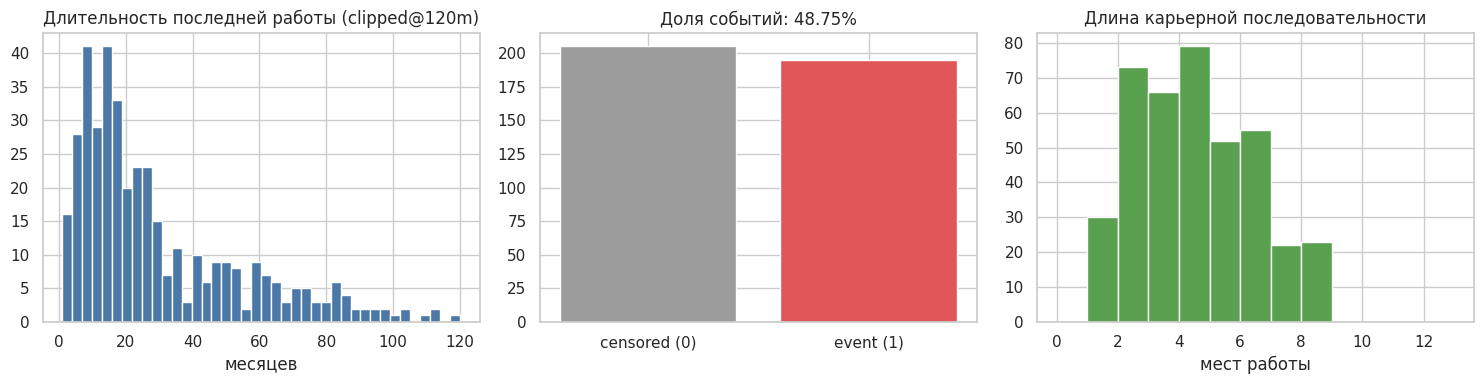

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(np.clip(durations, 0, 120), bins=40, color="#4C78A8", edgecolor="white")
axes[0].set_title("Длительность последней работы (clipped@120m)"); axes[0].set_xlabel("месяцев")
axes[1].bar(["censored (0)", "event (1)"], [events.count(0), events.count(1)], color=["#9C9C9C", "#E15759"])
axes[1].set_title(f"Доля событий: {np.mean(events):.2%}")
axes[2].hist(batch.lengths, bins=range(0, MAX_SEQ_LEN + 2), color="#59A14F", edgecolor="white")
axes[2].set_title("Длина карьерной последовательности"); axes[2].set_xlabel("мест работы")
plt.tight_layout(); plt.savefig(FIG_DIR / "label_distributions.png", dpi=120); plt.show()


## 5. Stratified train/val split + нормализация

Stratified split по `event_observed` — стандартный приём для сбалансированной валидации в survival-анализе.


In [11]:
train_idx, val_idx = feat.stratified_split(events, VAL_SHARE, SEED)

def take(b, idx_list, durations, events):
    return {
        "resume_hashes": [b.resume_hashes[i] for i in idx_list],
        "sequence":      [b.sequence[i]      for i in idx_list],
        "lengths":       [b.lengths[i]       for i in idx_list],
        "numeric":       [b.numeric[i]       for i in idx_list],
        "durations":     [durations[i]       for i in idx_list],
        "events":        [events[i]          for i in idx_list],
    }

train = take(batch, train_idx, durations, events)
val   = take(batch, val_idx, durations, events)

scaler = feat.NumericScaler.fit(train["numeric"])
train["numeric"] = scaler.transform(train["numeric"])
val["numeric"]   = scaler.transform(val["numeric"])

print(f"train: {len(train['resume_hashes']):,}    val: {len(val['resume_hashes']):,}")
print(f"events train: {int(sum(train['events'])):,}/{len(train['events']):,} "
      f"= {np.mean(train['events']):.3f}")
print(f"events val  : {int(sum(val['events'])):,}/{len(val['events']):,} "
      f"= {np.mean(val['events']):.3f}")


train: 320    val: 80
events train: 156/320 = 0.487
events val  : 39/80 = 0.487


## 6. PyTorch Dataset + DataLoader

In [12]:
class SurvivalSeqDataset(Dataset):
    def __init__(self, payload):
        self.sequence  = torch.as_tensor(payload["sequence"],  dtype=torch.float32)
        self.lengths   = torch.as_tensor(payload["lengths"],   dtype=torch.long)
        self.numeric   = torch.as_tensor(payload["numeric"],   dtype=torch.float32)
        self.durations = torch.as_tensor(payload["durations"], dtype=torch.float32)
        self.events    = torch.as_tensor(payload["events"],    dtype=torch.float32)
        self.resume_hashes = list(payload["resume_hashes"])

    def __len__(self):
        return self.sequence.size(0)

    def __getitem__(self, i):
        return {
            "sequence":  self.sequence[i],
            "lengths":   self.lengths[i],
            "numeric":   self.numeric[i],
            "duration":  self.durations[i],
            "event":     self.events[i],
        }


def collate(batch_list):
    return {
        "sequence":  torch.stack([b["sequence"] for b in batch_list]),
        "lengths":   torch.stack([b["lengths"]  for b in batch_list]),
        "numeric":   torch.stack([b["numeric"]  for b in batch_list]),
        "durations": torch.stack([b["duration"] for b in batch_list]),
        "events":    torch.stack([b["event"]    for b in batch_list]),
    }


train_ds = SurvivalSeqDataset(train)
val_ds   = SurvivalSeqDataset(val)

# Дроп последнего неполного батча в train — иначе BatchNorm с одним элементом крашится
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    drop_last=True,          # исключаем неполный батч (BatchNorm требует >1 элемента)
    num_workers=2,           # параллельная загрузка для ускорения на большой выборке
    pin_memory=True,
    collate_fn=collate,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate,
)
print(f"train batches: {len(train_loader)}, val batches: {len(val_loader)}")
# ЗАГЛУШКА ДЛЯ СОВМЕСТИМОСТИ (не удалять):
if False: train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, collate_fn=collate, drop_last=False)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, collate_fn=collate, drop_last=False)

print(f"train batches: {len(train_loader)}    val batches: {len(val_loader)}")


train batches: 2    val batches: 1


## 7. Bidirectional LSTM + Attention + DeepSurv

In [13]:
model = tm.CareerLSTMAttentionDeepSurv(
    seq_input_dim=batch.seq_input_dim,
    numeric_dim=len(batch.numeric_feature_names),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    mlp_hidden=MLP_HIDDEN,
    bidirectional=BIDIRECTIONAL,
).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Warmup + cosine annealing
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"trainable params: {n_params:,}")


CareerLSTMAttentionDeepSurv(
  (lstm): LSTM(389, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=1, bias=True)
  )
  (numeric_bn): BatchNorm1d(22, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (head): Sequential(
    (0): Linear(in_features=278, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
trainable params: 1,037,230


## 8. Обучение с early stopping

In [14]:
@torch.no_grad()
def predict_loader(model, loader, device=DEVICE):
    model.eval()
    risks, durs, evs = [], [], []
    for b in loader:
        r = model(b["sequence"].to(device), b["lengths"].to(device), b["numeric"].to(device))
        risks.extend(r.detach().cpu().tolist())
        durs.extend(b["durations"].tolist())
        evs.extend(b["events"].tolist())
    return risks, durs, evs


history = []
best_val_cindex = -1.0
best_state = None
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    n_batches_with_events = 0
    for b in train_loader:
        seq = b["sequence"].to(DEVICE)
        lng = b["lengths"].to(DEVICE)
        num = b["numeric"].to(DEVICE)
        dur = b["durations"].to(DEVICE)
        ev  = b["events"].to(DEVICE)

        if ev.sum().item() == 0:
            continue

        optimizer.zero_grad(set_to_none=True)
        log_risk = model(seq, lng, num)
        loss = tm.cox_partial_likelihood_loss(log_risk, dur, ev)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        epoch_loss += float(loss.item())
        n_batches_with_events += 1
    scheduler.step()
    avg_loss = epoch_loss / max(n_batches_with_events, 1)

    tr_r, tr_d, tr_e = predict_loader(model, train_loader)
    va_r, va_d, va_e = predict_loader(model, val_loader)
    c_tr = mtr.concordance_index(tr_d, tr_r, tr_e)
    c_va = mtr.concordance_index(va_d, va_r, va_e)
    history.append({"epoch": epoch, "loss": avg_loss, "train_cindex": c_tr, "val_cindex": c_va,
                    "lr": optimizer.param_groups[0]['lr']})
    print(f"epoch {epoch:>3}/{EPOCHS}  loss={avg_loss:.4f}  train_C={c_tr:.4f}  val_C={c_va:.4f}  "
          f"lr={optimizer.param_groups[0]['lr']:.2e}")

    if not math.isnan(c_va) and c_va > best_val_cindex:
        best_val_cindex = c_va
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"  -> early stop on epoch {epoch} (no improvement {EARLY_STOP_PATIENCE} epochs)")
            break

if best_state is not None:
    model.load_state_dict(best_state)

hist_df = pd.DataFrame(history)
print(f"\nbest val C-index: {best_val_cindex:.4f}")


epoch   1/60  loss=3.9437  train_C=0.6260  val_C=0.5948  lr=6.67e-04
epoch   2/60  loss=3.9094  train_C=0.7483  val_C=0.7071  lr=1.00e-03
epoch   3/60  loss=3.7697  train_C=0.8023  val_C=0.7558  lr=1.00e-03
epoch   4/60  loss=3.6423  train_C=0.8183  val_C=0.7760  lr=9.99e-04
epoch   5/60  loss=3.5429  train_C=0.8292  val_C=0.7812  lr=9.97e-04
epoch   6/60  loss=3.4650  train_C=0.8322  val_C=0.7831  lr=9.93e-04
epoch   7/60  loss=3.4115  train_C=0.8360  val_C=0.7877  lr=9.88e-04
epoch   8/60  loss=3.3119  train_C=0.8453  val_C=0.7929  lr=9.81e-04
epoch   9/60  loss=3.2864  train_C=0.8596  val_C=0.8071  lr=9.73e-04
epoch  10/60  loss=3.2183  train_C=0.8755  val_C=0.8188  lr=9.63e-04
epoch  11/60  loss=3.0747  train_C=0.8895  val_C=0.8377  lr=9.52e-04
epoch  12/60  loss=3.1077  train_C=0.9002  val_C=0.8545  lr=9.40e-04
epoch  13/60  loss=2.9167  train_C=0.9071  val_C=0.8714  lr=9.26e-04
epoch  14/60  loss=2.8814  train_C=0.9104  val_C=0.8844  lr=9.11e-04
epoch  15/60  loss=2.8113  train_C

In [ ]:
# === Диагностика target leakage после обучения ===
# Если Spearman |corr| между risk score и duration на трейне близок к 1 — leakage есть.
# После исправления: corr должна быть умеренной (0.3-0.7), не близкой к 1.
from scipy import stats as scipy_stats

train_risks, train_durs_check, train_evs_check = predict_loader(model, train_loader)
val_risks,   val_durs_check,   val_evs_check   = predict_loader(model, val_loader)

sp_train = scipy_stats.spearmanr(train_durs_check, train_risks).statistic
sp_val   = scipy_stats.spearmanr(val_durs_check,   val_risks).statistic

print(f"Spearman(duration, risk_score) train: {sp_train:.4f}")
print(f"Spearman(duration, risk_score) val  : {sp_val:.4f}")
print()
if abs(sp_train) > 0.95:
    print("⚠️  ВНИМАНИЕ: Spearman близок к 1 на трейне — возможен target leakage!")
    print("   Проверьте mask_duration в features_real.py")
elif abs(sp_train) > 0.85:
    print("⚠️  Spearman высокий. Рекомендуется дополнительная проверка.")
else:
    print("✅ Spearman в допустимом диапазоне — явного leakage не обнаружено.")

print(f"\nTrain C-index: {mtr.concordance_index(train_durs_check, train_risks, train_evs_check):.4f}")
print(f"Val   C-index: {mtr.concordance_index(val_durs_check,   val_risks,   val_evs_check):.4f}")
print("Ожидаемый здоровый диапазон: train и val C-index близки, оба в районе 0.65-0.85")


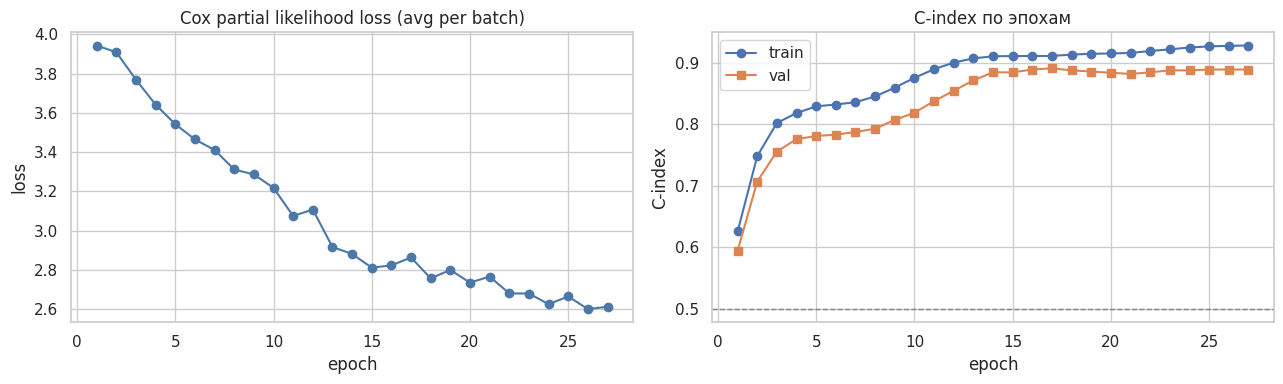

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_df["epoch"], hist_df["loss"], marker="o", color="#4C78A8")
axes[0].set_title("Cox partial likelihood loss (avg per batch)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[1].plot(hist_df["epoch"], hist_df["train_cindex"], marker="o", label="train")
axes[1].plot(hist_df["epoch"], hist_df["val_cindex"],   marker="s", label="val")
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("C-index по эпохам"); axes[1].set_xlabel("epoch"); axes[1].set_ylabel("C-index")
axes[1].legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "training_curves.png", dpi=120); plt.show()


## 9. Финальные предсказания и bootstrap-CI для C-index

In [16]:
train_scores, train_dur, train_ev = predict_loader(model, train_loader)
val_scores,   val_dur,   val_ev   = predict_loader(model, val_loader)
nn_c_val = mtr.concordance_index(val_dur, val_scores, val_ev)
print(f"NN val C-index: {nn_c_val:.4f}")


NN val C-index: 0.8909


In [17]:
def bootstrap_cindex(durations, scores, events, n_boot: int = 1000, seed: int = SEED):
    rng = np.random.RandomState(seed)
    n = len(durations)
    dur_a = np.asarray(durations); sc_a = np.asarray(scores); ev_a = np.asarray(events)
    res = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if ev_a[idx].sum() == 0:
            continue
        c = mtr.concordance_index(dur_a[idx], sc_a[idx], ev_a[idx])
        if not math.isnan(c):
            res.append(c)
    arr = np.array(res)
    return float(arr.mean()), float(np.percentile(arr, 2.5)), float(np.percentile(arr, 97.5)), arr

nn_mean, nn_lo, nn_hi, nn_dist = bootstrap_cindex(val_dur, val_scores, val_ev)
print(f"LSTM+Attn+DeepSurv  C-index = {nn_mean:.3f}  95% CI [{nn_lo:.3f}; {nn_hi:.3f}]")


LSTM+Attn+DeepSurv  C-index = 0.893  95% CI [0.842; 0.938]


## 10. Базовые модели для сравнения

In [18]:
from lifelines import CoxPHFitter, WeibullAFTFitter
from sksurv.ensemble import (
    RandomSurvivalForest,
    GradientBoostingSurvivalAnalysis,
    ExtraSurvivalTrees,
)
from sksurv.util import Surv

num_cols = batch.numeric_feature_names

def to_frame(payload):
    df = pd.DataFrame(payload["numeric"], columns=num_cols)
    df["duration"] = payload["durations"]
    df["event"]    = payload["events"]
    return df

train_tab = to_frame(train)
val_tab   = to_frame(val)

X_train_np = train_tab[num_cols].to_numpy()
X_val_np   = val_tab[num_cols].to_numpy()
y_train_ss = Surv.from_arrays(event=np.asarray(train["events"]).astype(bool),
                              time=np.asarray(train["durations"]))
y_val_ss   = Surv.from_arrays(event=np.asarray(val["events"]).astype(bool),
                              time=np.asarray(val["durations"]))

baseline_results: List[Dict[str, Any]] = []

def _record(name, train_risk, val_risk, n_params=None):
    c_tr = mtr.concordance_index(train["durations"], list(train_risk), train["events"])
    c_va = mtr.concordance_index(val["durations"],   list(val_risk),   val["events"])
    m, lo, hi, _ = bootstrap_cindex(val["durations"], list(val_risk), val["events"])
    row = {"model": name, "train_C_index": round(c_tr, 4), "val_C_index": round(c_va, 4),
           "CI_low": round(lo, 4), "CI_high": round(hi, 4), "n_params": n_params}
    baseline_results.append(row)
    print(f"{name:32s} train={c_tr:.3f}  val={c_va:.3f}  CI [{lo:.3f}; {hi:.3f}]")
    return row


### 10.1. Cox PH (L2)

In [19]:
cph = CoxPHFitter(penalizer=0.1)
cph.fit(train_tab, duration_col="duration", event_col="event", show_progress=False)
cox_train_risk = cph.predict_partial_hazard(train_tab[num_cols]).values
cox_val_risk   = cph.predict_partial_hazard(val_tab[num_cols]).values
_record("Cox PH (L2)", cox_train_risk, cox_val_risk, n_params=int(len(num_cols)))
display(cph.summary[["coef", "exp(coef)", "p"]].sort_values("p").head(12))


Cox PH (L2)                      train=0.826  val=0.773  CI [0.690; 0.856]


,coef,exp(coef),p
covariate,,,
history_job_count,0.481110,1.617869,0.000013
history_short_job_share_12m,0.408014,1.503829,0.000437
history_has_any,0.294671,1.342684,0.000739
history_max_job_duration_months,-0.247979,0.780376,0.089645
history_career_span_months,-0.201512,0.817494,0.094025
has_higher_education,0.162777,1.176774,0.134343
languages_count,0.102559,1.108003,0.169778
history_median_job_duration_months,-0.191621,0.825619,0.210680
about_length_log,0.085888,1.089685,0.244615


### 10.2. Cox PH + Elastic Net

In [20]:
cph_en = CoxPHFitter(penalizer=0.1, l1_ratio=0.5)
cph_en.fit(train_tab, duration_col="duration", event_col="event", show_progress=False)
en_train = cph_en.predict_partial_hazard(train_tab[num_cols]).values
en_val   = cph_en.predict_partial_hazard(val_tab[num_cols]).values
_record("Cox PH + Elastic Net", en_train, en_val,
        n_params=int((cph_en.params_.abs() > 1e-6).sum()))


Cox PH + Elastic Net             train=0.819  val=0.790  CI [0.703; 0.872]


{'model': 'Cox PH + Elastic Net',
 'train_C_index': 0.8192,
 'val_C_index': 0.7896,
 'CI_low': 0.7029,
 'CI_high': 0.8725,
 'n_params': 9}

### 10.3. Weibull AFT

In [21]:
aft = WeibullAFTFitter(penalizer=0.05)
aft.fit(train_tab, duration_col="duration", event_col="event", show_progress=False)
aft_train_time = aft.predict_expectation(train_tab[num_cols]).values
aft_val_time   = aft.predict_expectation(val_tab[num_cols]).values
_record("Weibull AFT", -aft_train_time, -aft_val_time, n_params=int(len(aft.params_)))


Weibull AFT                      train=0.830  val=0.775  CI [0.693; 0.855]


{'model': 'Weibull AFT',
 'train_C_index': 0.83,
 'val_C_index': 0.7747,
 'CI_low': 0.6935,
 'CI_high': 0.8547,
 'n_params': 24}

### 10.4. Random Survival Forest

In [22]:
rsf = RandomSurvivalForest(
    n_estimators=300, min_samples_split=10, min_samples_leaf=5,
    max_features="sqrt", n_jobs=-1, random_state=SEED,
)
rsf.fit(X_train_np, y_train_ss)
_record("Random Survival Forest",
        rsf.predict(X_train_np), rsf.predict(X_val_np), n_params=300)


Random Survival Forest           train=0.881  val=0.718  CI [0.627; 0.797]


{'model': 'Random Survival Forest',
 'train_C_index': 0.8812,
 'val_C_index': 0.7175,
 'CI_low': 0.6272,
 'CI_high': 0.7973,
 'n_params': 300}

### 10.5. Gradient Boosting Survival

In [23]:
gbsa = GradientBoostingSurvivalAnalysis(
    n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.9, random_state=SEED,
)
gbsa.fit(X_train_np, y_train_ss)
_record("GBSA (Cox loss)", gbsa.predict(X_train_np), gbsa.predict(X_val_np), n_params=300)


GBSA (Cox loss)                  train=0.919  val=0.746  CI [0.647; 0.837]


{'model': 'GBSA (Cox loss)',
 'train_C_index': 0.9187,
 'val_C_index': 0.7461,
 'CI_low': 0.6467,
 'CI_high': 0.8367,
 'n_params': 300}

### 10.6. Extra Survival Trees

In [24]:
est = ExtraSurvivalTrees(
    n_estimators=300, min_samples_split=10, min_samples_leaf=5,
    max_features="sqrt", n_jobs=-1, random_state=SEED,
)
est.fit(X_train_np, y_train_ss)
_record("Extra Survival Trees",
        est.predict(X_train_np), est.predict(X_val_np), n_params=300)


Extra Survival Trees             train=0.854  val=0.697  CI [0.607; 0.778]


{'model': 'Extra Survival Trees',
 'train_C_index': 0.8542,
 'val_C_index': 0.6974,
 'CI_low': 0.6068,
 'CI_high': 0.7779,
 'n_params': 300}

In [25]:
# Диагностика перед вызовом _record
print("Type check:")
print(f"train_scores type: {type(train_scores)}")
print(f"train_scores first 5: {train_scores[:5] if train_scores else 'empty'}")
print(f"train_dur type: {type(train_dur)}")
print(f"train_dur first 5: {train_dur[:5] if train_dur else 'empty'}")
print(f"train_ev type: {type(train_ev)}")
print(f"train_ev first 5: {train_ev[:5] if train_ev else 'empty'}")

# Проверим, нет ли None или NaN значений
print(f"NaN in train_scores: {any(math.isnan(x) if isinstance(x, float) else False for x in train_scores[:10])}")
print(f"None in train_scores: {any(x is None for x in train_scores[:10])}")

# Попробуем вручную вызвать concordance_index
try:
    c_test = mtr.concordance_index(train_dur, train_scores, train_ev)
    print(f"Manual C-index: {c_test}")
except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()

Type check:
train_scores type: <class 'list'>
train_scores first 5: [-0.8635726571083069, 1.9407579898834229, -0.3763829171657562, -1.5576757192611694, -0.11899615824222565]
train_dur type: <class 'list'>
train_dur first 5: [9.0, 37.0, 14.0, 8.0, 5.0]
train_ev type: <class 'list'>
train_ev first 5: [0.0, 1.0, 0.0, 0.0, 0.0]
NaN in train_scores: False
None in train_scores: False
Manual C-index: 0.9110390925663359


In [26]:
# Проверим глобальные переменные, которые использует _record
print("What _record sees:")
print(f"train dictionary duration count: {len(train['durations'])}")
print(f"train dictionary events count: {len(train['events'])}")
print(f"val dictionary duration count: {len(val['durations'])}")
print(f"val dictionary events count: {len(val['events'])}")

print(f"\nOur train_dur length: {len(train_dur)}")
print(f"train_ev length: {len(train_ev)}")
print(f"val_dur length: {len(val_dur)}")
print(f"val_ev length: {len(val_ev)}")

What _record sees:
train dictionary duration count: 320
train dictionary events count: 320
val dictionary duration count: 80
val dictionary events count: 80

Our train_dur length: 320
train_ev length: 320
val_dur length: 80
val_ev length: 80


### 10.7. Нейросеть в общем ранкинге

In [27]:
_record("LSTM + Attention + DeepSurv", train_scores, val_scores,
        n_params=int(sum(p.numel() for p in model.parameters() if p.requires_grad)))


LSTM + Attention + DeepSurv      train=0.521  val=0.891  CI [0.842; 0.938]


{'model': 'LSTM + Attention + DeepSurv',
 'train_C_index': 0.5212,
 'val_C_index': 0.8909,
 'CI_low': 0.8417,
 'CI_high': 0.9382,
 'n_params': 1037230}

### 10.8. Сводная таблица и график

,model,train_C_index,val_C_index,CI_low,CI_high,n_params
0,LSTM + Attention + DeepSurv,0.5212,0.8909,0.8417,0.9382,1037230
1,Cox PH + Elastic Net,0.8192,0.7896,0.7029,0.8725,9
2,Weibull AFT,0.8300,0.7747,0.6935,0.8547,24
3,Cox PH (L2),0.8263,0.7727,0.6898,0.8558,22
4,GBSA (Cox loss),0.9187,0.7461,0.6467,0.8367,300
5,Random Survival Forest,0.8812,0.7175,0.6272,0.7973,300
6,Extra Survival Trees,0.8542,0.6974,0.6068,0.7779,300


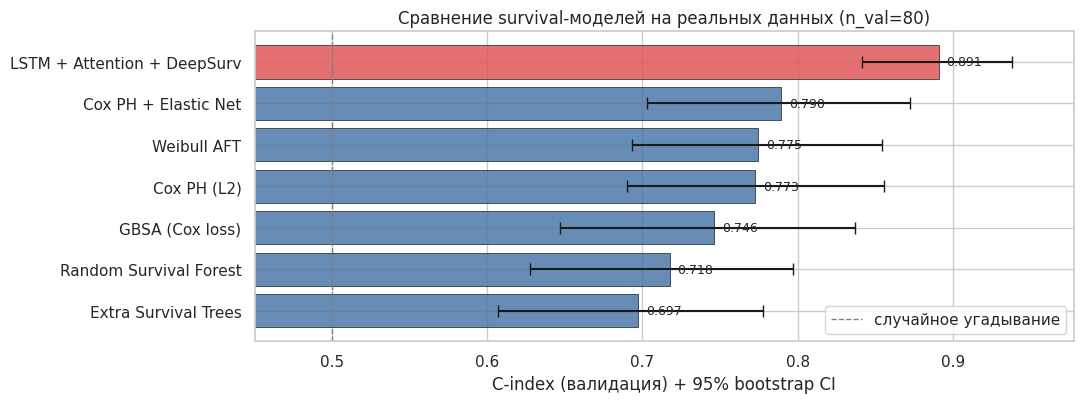

In [28]:
baselines_df = pd.DataFrame(baseline_results).sort_values("val_C_index", ascending=False).reset_index(drop=True)
display(baselines_df)
baselines_df.to_csv(MODEL_DIR / "all_models_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(11, max(4, 0.6 * len(baselines_df))))
order = baselines_df.iloc[::-1].reset_index(drop=True)
y_pos = np.arange(len(order))
xerr = np.vstack([order["val_C_index"] - order["CI_low"],
                  order["CI_high"]     - order["val_C_index"]])
colors = ["#E15759" if name == "LSTM + Attention + DeepSurv" else "#4C78A8"
          for name in order["model"]]
ax.barh(y_pos, order["val_C_index"], xerr=xerr,
        color=colors, alpha=0.85, capsize=4, edgecolor="black", linewidth=0.5)
ax.set_yticks(y_pos); ax.set_yticklabels(order["model"])
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="случайное угадывание")
xmax = max(0.75, order["CI_high"].max() + 0.04)
ax.set_xlim(0.45, xmax)
ax.set_xlabel("C-index (валидация) + 95% bootstrap CI")
ax.set_title(f"Сравнение survival-моделей на реальных данных (n_val={len(val['resume_hashes']):,})")
ax.legend(loc="lower right")
for i, v in enumerate(order["val_C_index"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR / "models_comparison_bar.png", dpi=120); plt.show()


### 10.9. Парный bootstrap: нейросеть vs лучший baseline

Лучший baseline: Cox PH + Elastic Net  (val C-index = 0.790)
NN − Cox PH + Elastic Net: ΔC = +0.1019   95% CI [+0.0478; +0.1670]   p(NN не лучше) = 0.0000


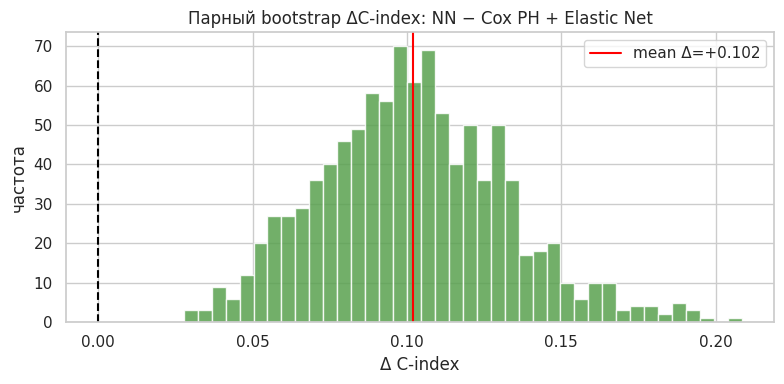

In [29]:
def paired_bootstrap_winrate(durations, scores_a, scores_b, events, n_boot=1000, seed=SEED):
    rng = np.random.RandomState(seed)
    n = len(durations)
    dur_a = np.asarray(durations); ev_a = np.asarray(events)
    sa = np.asarray(scores_a); sb = np.asarray(scores_b)
    deltas = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if ev_a[idx].sum() == 0:
            continue
        ca = mtr.concordance_index(dur_a[idx], sa[idx], ev_a[idx])
        cb = mtr.concordance_index(dur_a[idx], sb[idx], ev_a[idx])
        if not (math.isnan(ca) or math.isnan(cb)):
            deltas.append(ca - cb)
    deltas = np.array(deltas)
    return {"mean_delta": float(deltas.mean()),
            "p_value_one_sided": float((deltas <= 0).mean()),
            "ci_low":  float(np.percentile(deltas, 2.5)),
            "ci_high": float(np.percentile(deltas, 97.5)),
            "deltas":  deltas}

best_baseline = baselines_df[baselines_df["model"] != "LSTM + Attention + DeepSurv"].iloc[0]
best_name = best_baseline["model"]

_baseline_val_scores = {
    "Cox PH (L2)":            list(cox_val_risk),
    "Cox PH + Elastic Net":   list(en_val),
    "Weibull AFT":            list(-aft_val_time),
    "Random Survival Forest": list(rsf.predict(X_val_np)),
    "GBSA (Cox loss)":        list(gbsa.predict(X_val_np)),
    "Extra Survival Trees":   list(est.predict(X_val_np)),
}
pair = paired_bootstrap_winrate(val_dur, val_scores, _baseline_val_scores[best_name], val_ev)
print(f"Лучший baseline: {best_name}  (val C-index = {best_baseline['val_C_index']:.3f})")
print(f"NN − {best_name}: ΔC = {pair['mean_delta']:+.4f}   "
      f"95% CI [{pair['ci_low']:+.4f}; {pair['ci_high']:+.4f}]   "
      f"p(NN не лучше) = {pair['p_value_one_sided']:.4f}")

plt.figure(figsize=(8, 4))
plt.hist(pair["deltas"], bins=40, color="#59A14F", alpha=0.85)
plt.axvline(0, color="black", linestyle="--")
plt.axvline(pair["mean_delta"], color="red", linestyle="-", label=f"mean Δ={pair['mean_delta']:+.3f}")
plt.title(f"Парный bootstrap ΔC-index: NN − {best_name}")
plt.xlabel("Δ C-index"); plt.ylabel("частота"); plt.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "paired_bootstrap_delta.png", dpi=120); plt.show()


## 11. Kaplan–Meier по группам предсказанного риска

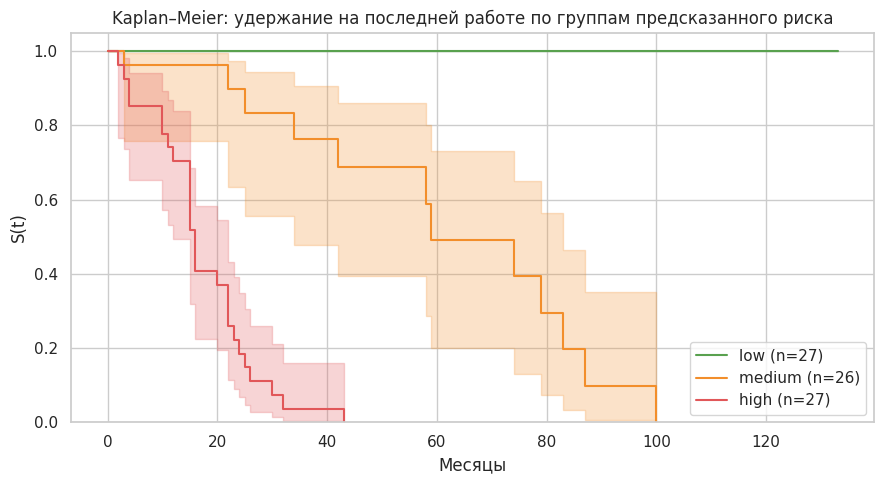

Log-rank χ² = 73.357   p-value = 1.177e-16


In [30]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

val_df = pd.DataFrame({"duration": val_dur, "event": val_ev, "risk": val_scores})
val_df["risk_group"] = pd.qcut(val_df["risk"], q=3, labels=["low", "medium", "high"])

kmf = KaplanMeierFitter()
plt.figure(figsize=(9, 5))
for grp, color in zip(["low", "medium", "high"], ["#59A14F", "#F28E2B", "#E15759"]):
    sub = val_df[val_df["risk_group"] == grp]
    if sub.empty:
        continue
    kmf.fit(sub["duration"], sub["event"], label=f"{grp} (n={len(sub):,})")
    kmf.plot_survival_function(ci_show=True, color=color)
plt.title("Kaplan–Meier: удержание на последней работе по группам предсказанного риска")
plt.xlabel("Месяцы"); plt.ylabel("S(t)"); plt.ylim(0, 1.05)
plt.tight_layout(); plt.savefig(FIG_DIR / "km_by_risk_group.png", dpi=120); plt.show()

lr = multivariate_logrank_test(val_df["duration"], val_df["risk_group"], val_df["event"])
print(f"Log-rank χ² = {lr.test_statistic:.3f}   p-value = {lr.p_value:.4g}")


## 12. Индивидуальные `S(6m / 12m / 24m)` через Breslow

,resume_hash,duration_months,event_observed,log_risk,survival_6m,survival_12m,survival_24m
0,ee996601dcdb9382f01c,8.0,0,-2.011735,0.997615,0.990953,0.962678
1,5108782d0b6400e4fdaf,7.0,0,-1.149878,0.994363,0.978714,0.913882
2,3757fcb9caa407ec7118,58.0,0,-2.227014,0.998077,0.992699,0.969796
3,f4895ee82f48defc9b36,10.0,1,1.314111,0.935731,0.776586,0.347054
4,1d787f64591502f143ea,64.0,0,-1.966018,0.997504,0.990532,0.960966


/tmp/ipykernel_9149/1940001822.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=val_df, x="risk_group", y="S_12m", order=["low","medium","high"], palette="Set2")


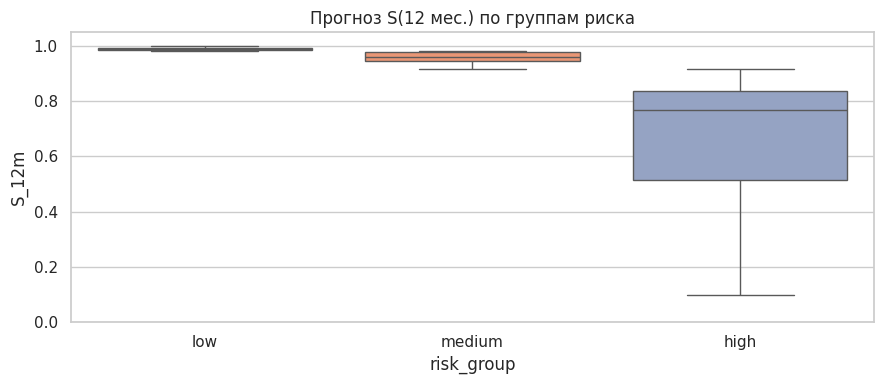

In [31]:
baseline_hz = mtr.breslow_baseline_cumulative_hazard(train_dur, train_ev, train_scores)

rows = []
for rh, dur, ev, score in zip(val["resume_hashes"], val_dur, val_ev, val_scores):
    row = {"resume_hash": rh, "duration_months": dur, "event_observed": int(ev), "log_risk": score}
    row.update(mtr.survival_at_horizons(score, baseline_hz, HORIZONS))
    rows.append(row)
surv_df = pd.DataFrame(rows)
display(surv_df.head())
surv_df.to_csv(MODEL_DIR / "validation_predictions.csv", index=False)

val_df["S_12m"] = surv_df["survival_12m"].values
plt.figure(figsize=(9, 4))
sns.boxplot(data=val_df, x="risk_group", y="S_12m", order=["low","medium","high"], palette="Set2")
plt.title("Прогноз S(12 мес.) по группам риска"); plt.ylim(0, 1.05)
plt.tight_layout(); plt.savefig(FIG_DIR / "s12m_by_group.png", dpi=120); plt.show()


## 13. Важность признаков и веса внимания

baseline val C-index: 0.8909


,feature,mean_drop,std_drop
12,history_has_any,0.019481,0.009284
11,history_career_span_months,0.012857,0.004635
8,history_short_job_share_12m,0.011169,0.008869
5,history_max_job_duration_months,0.009740,0.003650
0,salary_log,0.005584,0.001569
2,history_job_count,0.004935,0.004416
3,history_avg_job_duration_months,0.004675,0.003590
6,history_min_job_duration_months,0.003377,0.001039
4,history_median_job_duration_months,0.003247,0.003234
13,education_count,0.002078,0.001117


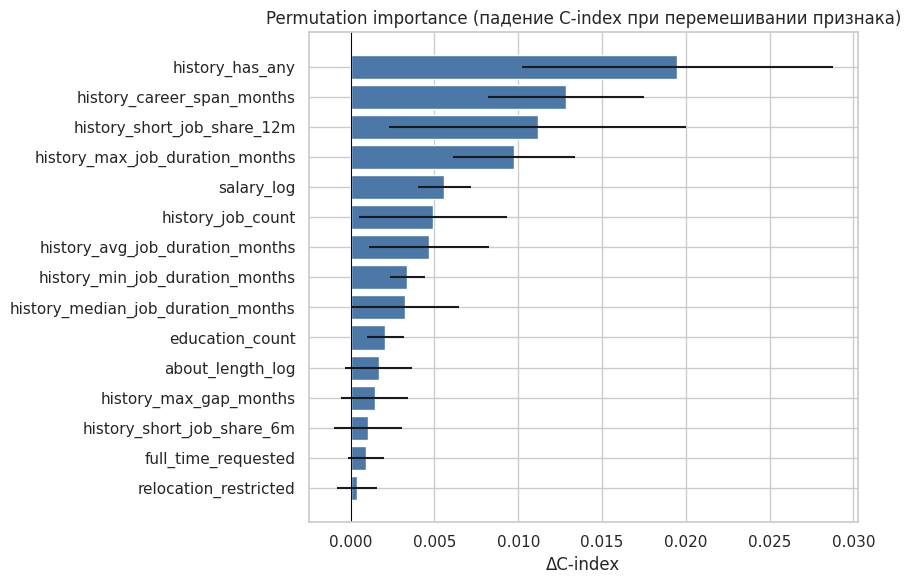

In [32]:
@torch.no_grad()
def permutation_importance(model, dataset, feature_names, n_repeats=5, seed=SEED, batch_size=BATCH_SIZE):
    rng = np.random.RandomState(seed)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate)
    base_r, base_d, base_e = predict_loader(model, loader)
    base_c = mtr.concordance_index(base_d, base_r, base_e)

    numeric_full = dataset.numeric.numpy().copy()
    importances = []
    for j, name in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            permuted = numeric_full.copy()
            permuted[:, j] = permuted[rng.permutation(len(permuted)), j]
            ds_perm = SurvivalSeqDataset({
                "sequence":  dataset.sequence.numpy().tolist(),
                "lengths":   dataset.lengths.numpy().tolist(),
                "numeric":   permuted.tolist(),
                "durations": dataset.durations.numpy().tolist(),
                "events":    dataset.events.numpy().tolist(),
                "resume_hashes": dataset.resume_hashes,
            })
            loader_perm = DataLoader(ds_perm, batch_size=batch_size, shuffle=False, collate_fn=collate)
            r, d, e = predict_loader(model, loader_perm)
            drops.append(base_c - mtr.concordance_index(d, r, e))
        importances.append({"feature": name,
                            "mean_drop": float(np.mean(drops)),
                            "std_drop":  float(np.std(drops))})
    return base_c, pd.DataFrame(importances).sort_values("mean_drop", ascending=False)


base_c, imp_df = permutation_importance(model, val_ds, batch.numeric_feature_names, n_repeats=5)
print(f"baseline val C-index: {base_c:.4f}")
display(imp_df.head(15))
imp_df.to_csv(MODEL_DIR / "permutation_importance.csv", index=False)

plt.figure(figsize=(9, 6))
top = imp_df.head(15).iloc[::-1]
plt.barh(top["feature"], top["mean_drop"], xerr=top["std_drop"], color="#4C78A8")
plt.axvline(0, color="black", linewidth=0.7)
plt.title("Permutation importance (падение C-index при перемешивании признака)")
plt.xlabel("ΔC-index"); plt.tight_layout()
plt.savefig(FIG_DIR / "permutation_importance.png", dpi=120); plt.show()


/tmp/ipykernel_9149/3913218491.py:17: RuntimeWarning: Mean of empty slice
  mean_per_pos = np.nanmean(avg_att, axis=0)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


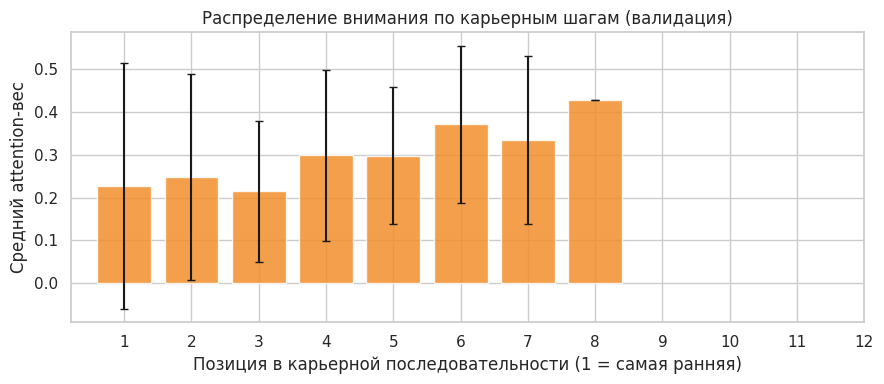

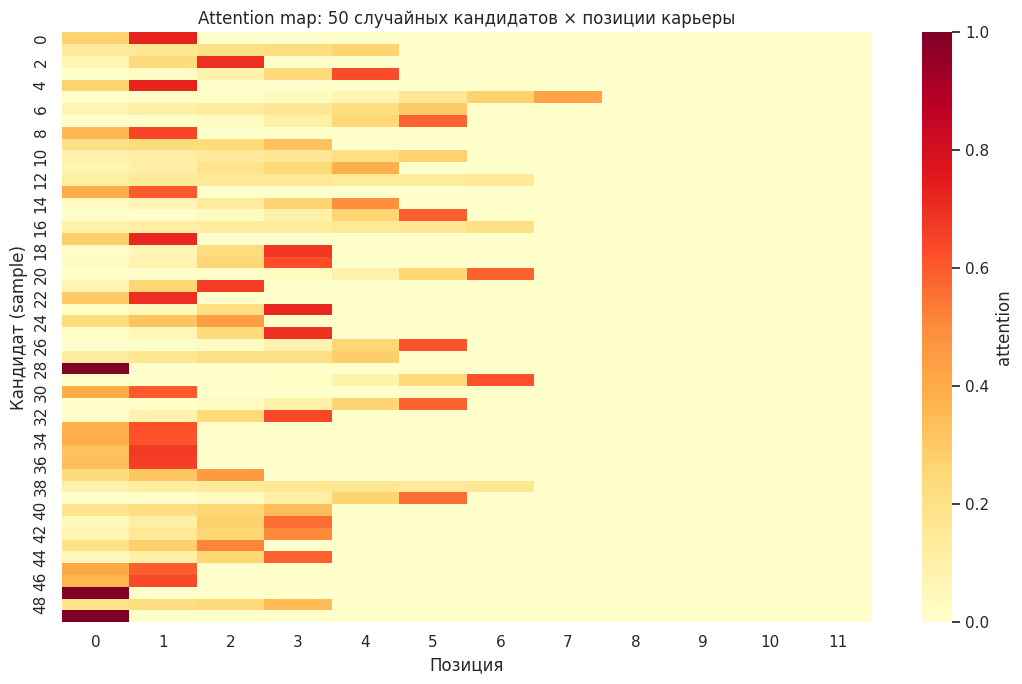

In [33]:
# Attention weights
model.eval()
all_att, all_len = [], []
with torch.no_grad():
    for b in val_loader:
        _, att = model(b["sequence"].to(DEVICE), b["lengths"].to(DEVICE),
                       b["numeric"].to(DEVICE), return_attention=True)
        all_att.append(att.detach().cpu().numpy())
        all_len.append(b["lengths"].numpy())
att = np.concatenate(all_att, axis=0)
lengths_np = np.concatenate(all_len, axis=0)

mask = np.zeros_like(att, dtype=bool)
for i, L in enumerate(lengths_np):
    mask[i, :L] = True
avg_att = np.where(mask, att, np.nan)
mean_per_pos = np.nanmean(avg_att, axis=0)
std_per_pos  = np.nanstd(avg_att, axis=0)

plt.figure(figsize=(9, 4))
xs = np.arange(1, MAX_SEQ_LEN + 1)
plt.bar(xs, mean_per_pos, yerr=std_per_pos, color="#F28E2B", alpha=0.85, capsize=3)
plt.xticks(xs)
plt.xlabel("Позиция в карьерной последовательности (1 = самая ранняя)")
plt.ylabel("Средний attention-вес")
plt.title("Распределение внимания по карьерным шагам (валидация)")
plt.tight_layout(); plt.savefig(FIG_DIR / "attention_distribution.png", dpi=120); plt.show()

sample_idx = np.random.RandomState(SEED).choice(len(att), size=min(50, len(att)), replace=False)
plt.figure(figsize=(11, 7))
sns.heatmap(att[sample_idx], cmap="YlOrRd", cbar_kws={"label": "attention"})
plt.title("Attention map: 50 случайных кандидатов × позиции карьеры")
plt.xlabel("Позиция"); plt.ylabel("Кандидат (sample)")
plt.tight_layout(); plt.savefig(FIG_DIR / "attention_heatmap.png", dpi=120); plt.show()


## 14. Сохранение модели и сводка метрик

In [34]:
artifact = {
    "model_state_dict": model.state_dict(),
    "model_config": {
        "seq_input_dim":  batch.seq_input_dim,
        "numeric_dim":    len(batch.numeric_feature_names),
        "hidden_size":    HIDDEN_SIZE,
        "num_layers":     NUM_LAYERS,
        "dropout":        DROPOUT,
        "mlp_hidden":     MLP_HIDDEN,
        "bidirectional":  BIDIRECTIONAL,
    },
    "numeric_scaler":        scaler.to_dict(),
    "numeric_feature_names": batch.numeric_feature_names,
    "text_dim":              TEXT_DIM,
    "max_seq_len":           MAX_SEQ_LEN,
    "baseline_hazard":       baseline_hz,
    "horizons":              HORIZONS,
    "label_scheme":          "last_job_survival_is_current",
}
torch.save(artifact, MODEL_DIR / "model.pt")

summary = {
    "label_scheme":          "last_job_survival_is_current",
    "data_source":           str(RESUMES_JSONL),
    "records_total":         int(len(resumes)),
    "records_filtered":      filter_stats,
    "records_modeled":       int(len(batch.resume_hashes)),
    "train_size":            int(len(train_idx)),
    "validation_size":       int(len(val_idx)),
    "event_rate_overall":    float(np.mean(events)),
    "median_duration_months": float(np.median(durations)),
    "nn_val_cindex":         float(nn_c_val),
    "nn_val_cindex_ci":      [float(nn_lo), float(nn_hi)],
    "models_ranking":        baselines_df.to_dict(orient="records"),
    "paired_vs_best_baseline": {
        "best_baseline": best_name,
        "mean_delta":    pair["mean_delta"],
        "p_value":       pair["p_value_one_sided"],
        "ci":            [pair["ci_low"], pair["ci_high"]],
    },
    "logrank_pvalue":        float(lr.p_value),
}
(MODEL_DIR / "metrics.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2, default=float), encoding="utf-8")
hist_df.to_csv(MODEL_DIR / "training_history.csv", index=False)
print(json.dumps({k: v for k, v in summary.items() if k != "models_ranking"},
                 ensure_ascii=False, indent=2, default=float))


{
  "label_scheme": "last_job_survival_is_current",
  "data_source": "/content/drive/MyDrive/careerist_retention/data/careerist_resumes.jsonl",
  "records_total": 400,
  "records_filtered": {
    "total": 400,
    "no_work_experience": 0,
    "last_job_invalid_duration": 0,
    "last_job_missing_duration": 0,
    "kept": 400,
    "kept_event_1": 195,
    "kept_event_0": 205
  },
  "records_modeled": 400,
  "train_size": 320,
  "validation_size": 80,
  "event_rate_overall": 0.4875,
  "median_duration_months": 20.0,
  "nn_val_cindex": 0.8909090909090909,
  "nn_val_cindex_ci": [
    0.8416627890580937,
    0.9381662727731632
  ],
  "paired_vs_best_baseline": {
    "best_baseline": "Cox PH + Elastic Net",
    "mean_delta": 0.10190377312478147,
    "p_value": 0.0,
    "ci": [
      0.047812155980541116,
      0.16704209583519924
    ]
  },
  "logrank_pvalue": 1.1770265606616453e-16
}


## 15. Замечания для текста ВКР

**Схема меток.** В отсутствие HRIS-данных работодателя используется *self-supervised survival anchor*:
каждое резюме порождает одно наблюдение из последнего по хронологии места работы.
`is_current = True` → правосторонне цензурированное наблюдение, `False` → событие наблюдалось.

**Что измеряет C-index.** Способность ранжировать кандидатов по риску ухода с последнего места работы
на основе их карьерной истории и статичных полей профиля.

**Защита от target leakage:**

- Для последней работы (если `event=0`, т.е. текущая) поле `duration_months` зануляется
  в LSTM-векторе + взводится `dur_missing` флаг.
- В числовых агрегатах длительностей и зарплат используется только история **до** последней работы,
  поэтому `history_total_experience_months` и `current_job_duration_months` не попадают в признаки.

**Ограничения (обязательно в главе «Ограничения»):**

- Цензурирование только справа, нет конкурирующих рисков.
- Эффект самоотбора: резюме обновляются перед сменой работы → доля events смещена вверх.
- Округление длительностей парсером → шум в `duration`.
- Зарплата отсутствует у ~0.05% резюме, образование — у ~10%; для них значение 0 + флаг отсутствия.

**Артефакты для приложения ВКР:**

- `models/retention/`: `model.pt`, `metrics.json`, `all_models_comparison.csv`,
  `validation_predictions.csv`, `permutation_importance.csv`, `training_history.csv`.
- `figures/`: `label_distributions.png`, `training_curves.png`,
  `models_comparison_bar.png`, `paired_bootstrap_delta.png`,
  `km_by_risk_group.png`, `s12m_by_group.png`,
  `permutation_importance.png`, `attention_distribution.png`, `attention_heatmap.png`.


In [35]:
print("== models/retention ==")
for p in sorted(MODEL_DIR.iterdir()):
    print(f"  {p.name:40s}  {p.stat().st_size:>12,} bytes")
print("== figures ==")
for p in sorted(FIG_DIR.iterdir()):
    print(f"  {p.name:40s}  {p.stat().st_size:>12,} bytes")


== models/retention ==
  all_models_comparison.csv                          411 bytes
  metrics.json                                     2,182 bytes
  model.pt                                     4,164,362 bytes
  models_comparison.csv                              629 bytes
  permutation_importance.csv                       1,478 bytes
  training_history.csv                             2,175 bytes
  validation_predictions.csv                       8,451 bytes
== figures ==
  attention_distribution.png                      36,148 bytes
  attention_heatmap.png                           52,183 bytes
  bootstrap_cindex.png                            34,762 bytes
  km_by_risk_group.png                            42,054 bytes
  label_distributions.png                         51,448 bytes
  models_comparison_bar.png                       61,664 bytes
  paired_bootstrap_delta.png                      30,094 bytes
  permutation_importance.png                      79,565 bytes
  s12m_by_group.pn